# Lab Activity 2 - Exploratory Data Analysis
# IT325 Machine Learning | Alzheimer's Disease Dataset

A comprehensive EDA on whether the diagnosis indicates Alzheimer’s disease based on patient features.

In [1]:
#lib imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

# 1. load dataset and display first few rows -------------

In [2]:
import pandas as pd

df = pd.read_csv('Gonzales_AlzheimersDisease.csv')

print("\nFirst 5 Rows:")
display(df.head())

print("\nLast 5 Rows:")
display(df.tail())


First 5 Rows:


,PatientID,Age,BMI,Smoking,PhysicalActivity,FamilyHistoryAlzheimers,CardiovascularDisease,Diabetes,Depression,Hypertension,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,Disorientation,DifficultyCompletingTasks,Forgetfulness,Gender,EducationLevel,HeadInjury,Diagnosis
0,4751,73,22.927749,0,6.327112,0,0,1,1,0,...,6.518877,0,0,0,1,0,0,2,0,0
1,4752,89,26.827681,0,7.619885,0,0,0,0,0,...,7.118696,0,0,0,0,1,0,0,0,0
2,4753,73,17.795882,0,7.844988,1,0,0,0,0,...,5.895077,0,0,1,1,0,0,1,0,0
3,4754,74,33.800817,1,8.428001,0,0,0,0,0,...,8.965106,0,1,0,0,0,1,1,0,0
4,4755,89,20.716974,0,6.310461,0,0,0,0,0,...,6.045039,0,0,0,1,0,0,0,0,0



Last 5 Rows:


,PatientID,Age,BMI,Smoking,PhysicalActivity,FamilyHistoryAlzheimers,CardiovascularDisease,Diabetes,Depression,Hypertension,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,Disorientation,DifficultyCompletingTasks,Forgetfulness,Gender,EducationLevel,HeadInjury,Diagnosis
2144,6895,61,39.121757,0,4.049964,0,0,0,0,0,...,0.238667,0,0,0,0,0,0,1,0,1
2145,6896,75,17.857903,0,1.360667,0,0,0,0,0,...,8.687480,0,1,0,0,0,0,2,0,1
2146,6897,77,15.476479,0,9.886002,0,0,0,0,0,...,1.972137,0,0,0,0,0,0,1,0,1
2147,6898,78,15.299911,0,6.354282,0,1,0,0,0,...,5.173891,0,0,0,0,1,1,1,0,1
2148,6899,72,33.289738,0,6.570993,0,0,0,0,0,...,6.307543,0,1,1,0,1,0,2,0,0


# 2. dataset shape, column names, and data types -------------

In [3]:
print("Shape:", df.shape)
print(f"\nRows: {df.shape[0]}  |  Columns: {df.shape[1]}")

print("\nColumn Names:\n", df.columns.tolist())

print("\nData Types:\n")
print(df.dtypes)

print("\nBasic Statistics:\n")
df.describe()

Shape: (2149, 21)

Rows: 2149  |  Columns: 21

Column Names:
 ['PatientID', 'Age', 'BMI', 'Smoking', 'PhysicalActivity', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'Hypertension', 'MMSE', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'Disorientation', 'DifficultyCompletingTasks', 'Forgetfulness', 'Gender', 'EducationLevel', 'HeadInjury', 'Diagnosis']

Data Types:

PatientID                      int64
Age                            int64
BMI                          float64
Smoking                        int64
PhysicalActivity             float64
FamilyHistoryAlzheimers        int64
CardiovascularDisease          int64
Diabetes                       int64
Depression                     int64
Hypertension                   int64
MMSE                         float64
FunctionalAssessment         float64
MemoryComplaints               int64
BehavioralProblems             int64
Disorientation                 int64
DifficultyCompletingTas

,PatientID,Age,BMI,Smoking,PhysicalActivity,FamilyHistoryAlzheimers,CardiovascularDisease,Diabetes,Depression,Hypertension,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,Disorientation,DifficultyCompletingTasks,Forgetfulness,Gender,EducationLevel,HeadInjury,Diagnosis
count,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,...,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000
mean,5825.000000,74.908795,27.655697,0.288506,4.920202,0.252210,0.144253,0.150768,0.200558,0.148906,...,5.080055,0.208004,0.156817,0.158213,0.158678,0.301536,0.506282,1.286645,0.092601,0.353653
std,620.507185,8.990221,7.217438,0.453173,2.857191,0.434382,0.351428,0.357906,0.400511,0.356079,...,2.892743,0.405974,0.363713,0.365026,0.365461,0.459032,0.500077,0.904527,0.289940,0.478214
min,4751.000000,60.000000,15.008851,0.000000,0.003616,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000460,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5288.000000,67.000000,21.611408,0.000000,2.570626,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.566281,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,5825.000000,75.000000,27.823924,0.000000,4.766424,0.000000,0.000000,0.000000,0.000000,0.000000,...,5.094439,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
75%,6362.000000,83.000000,33.869778,1.000000,7.427899,1.000000,0.000000,0.000000,0.000000,0.000000,...,7.546981,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,2.000000,0.000000,1.000000
max,6899.000000,90.000000,39.992767,1.000000,9.987429,1.000000,1.000000,1.000000,1.000000,1.000000,...,9.996467,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000


# 3. missing values and duplicate rows -------------

In [4]:
# Missing Values
print("=== Missing Values ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "No missing values found.")

# Duplicate Rows
print("\n=== Duplicate Rows ===")
dupes = df.duplicated().sum()
print(f"Number of duplicate rows: {dupes}")

=== Missing Values ===
No missing values found.

=== Duplicate Rows ===
Number of duplicate rows: 0


# 4. target variable distribution -------------

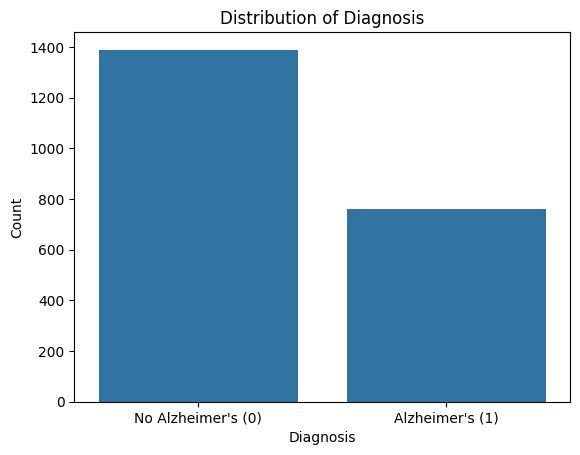

=== Diagnosis Class Distribution ===
Diagnosis
No Alzheimer's (0)    1389
Alzheimer's (1)        760
Name: count, dtype: int64

Class Ratio  —  0: 64.6%  |  1: 35.4%


In [5]:
plt.figure()
sns.countplot(x='Diagnosis', data=df)
plt.title("Distribution of Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.xticks([0, 1], ['No Alzheimer\'s (0)', 'Alzheimer\'s (1)'])
plt.show()

print("=== Diagnosis Class Distribution ===")
counts = df['Diagnosis'].value_counts()
labels = {0: 'No Alzheimer\'s (0)', 1: 'Alzheimer\'s (1)'}
print(counts.rename(index=labels))
print(f"\nClass Ratio  —  0: {counts[0]/len(df)*100:.1f}%  |  1: {counts[1]/len(df)*100:.1f}%")

# 5. EDA visualizations -------------

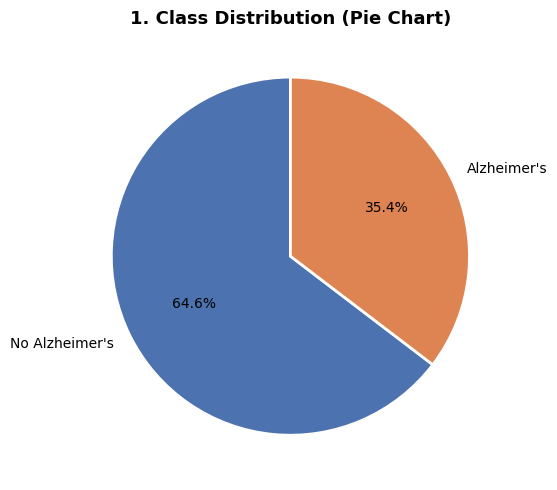

In [6]:
diagnosis_labels = {0: "No Alzheimer's", 1: "Alzheimer's"}
df['Diagnosis_Label'] = df['Diagnosis'].map(diagnosis_labels)
colors = ['#4C72B0', '#DD8452']

counts = df['Diagnosis_Label'].value_counts()
fig, ax = plt.subplots(figsize=(7, 5))
ax.pie(counts.values, labels=counts.index, colors=colors, autopct='%1.1f%%',
       startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title("1. Class Distribution (Pie Chart)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

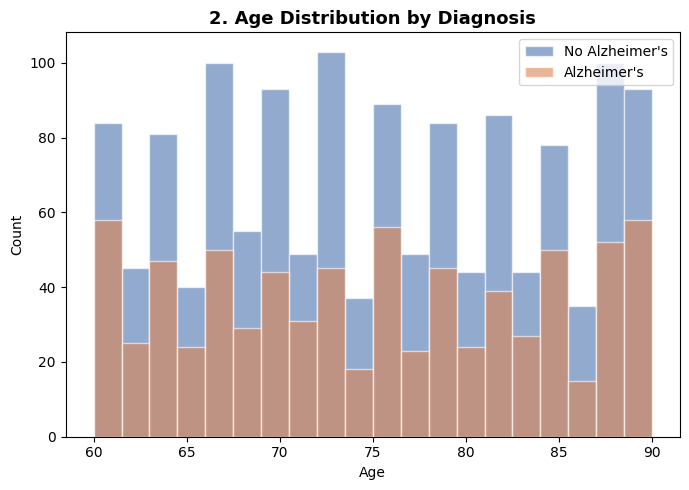

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
for label, color in zip(["No Alzheimer's", "Alzheimer's"], colors):
    subset = df[df['Diagnosis_Label'] == label]['Age']
    ax.hist(subset, bins=20, alpha=0.6, label=label, color=color, edgecolor='white')
ax.set_title("2. Age Distribution by Diagnosis", fontsize=13, fontweight='bold')
ax.set_xlabel("Age")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

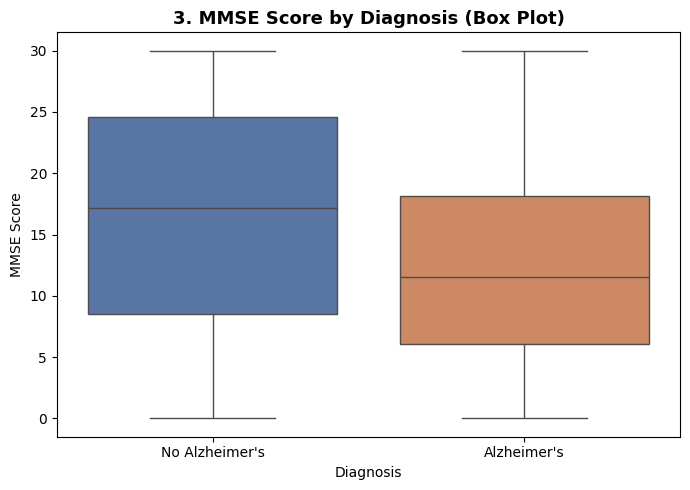

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x='Diagnosis_Label', y='MMSE', hue='Diagnosis_Label',
            palette=colors, ax=ax, order=["No Alzheimer's", "Alzheimer's"], legend=False)
ax.set_title("3. MMSE Score by Diagnosis (Box Plot)", fontsize=13, fontweight='bold')
ax.set_xlabel("Diagnosis")
ax.set_ylabel("MMSE Score")
plt.tight_layout()
plt.show()

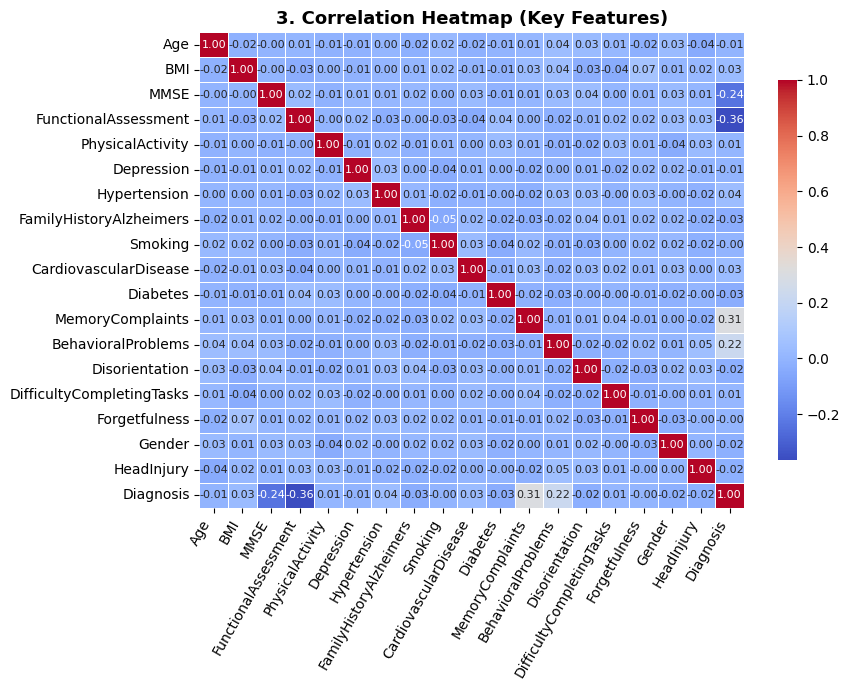

In [9]:
key_cols = ['Age', 'BMI', 'MMSE', 'FunctionalAssessment',
            'PhysicalActivity', 'Depression', 'Hypertension',
            'FamilyHistoryAlzheimers', 'Smoking', 'CardiovascularDisease', 
            'Diabetes', 'MemoryComplaints', 'BehavioralProblems', 'Disorientation',
            'DifficultyCompletingTasks', 'Forgetfulness', 'Gender', 'HeadInjury',
            'Diagnosis',
           ]
corr = df[key_cols].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5,
            ax=ax, annot_kws={"size": 8}, cbar_kws={"shrink": 0.8})
ax.set_title("3. Correlation Heatmap (Key Features)", fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha='right')
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

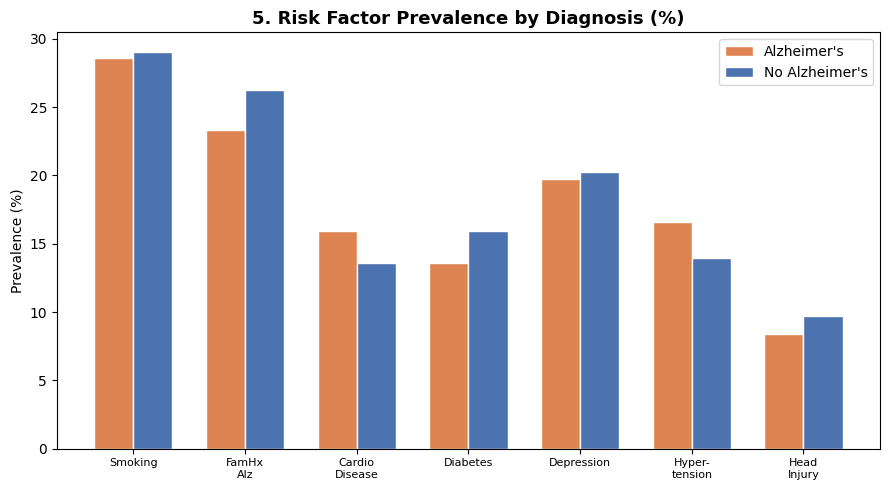

In [10]:
risk_factors = ['Smoking', 'FamilyHistoryAlzheimers', 'CardiovascularDisease',
                'Diabetes', 'Depression', 'Hypertension', 'HeadInjury']
risk_pct = []
for factor in risk_factors:
    pct_alz = df[df['Diagnosis'] == 1][factor].mean() * 100
    pct_no  = df[df['Diagnosis'] == 0][factor].mean() * 100
    risk_pct.append((factor, pct_alz, pct_no))

risk_df = pd.DataFrame(risk_pct, columns=['Factor', "Alzheimer's", "No Alzheimer's"])
x = np.arange(len(risk_factors))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, risk_df["Alzheimer's"],    width=w, label="Alzheimer's",    color=colors[1], edgecolor='white')
ax.bar(x + w/2, risk_df["No Alzheimer's"], width=w, label="No Alzheimer's", color=colors[0], edgecolor='white')
ax.set_title("5. Risk Factor Prevalence by Diagnosis (%)", fontsize=13, fontweight='bold')
ax.set_ylabel("Prevalence (%)")
ax.set_xticks(x)
ax.set_xticklabels(['Smoking', 'FamHx\nAlz', 'Cardio\nDisease',
                    'Diabetes', 'Depression', 'Hyper-\ntension', 'Head\nInjury'], fontsize=8)
ax.legend()
plt.tight_layout()
plt.show()

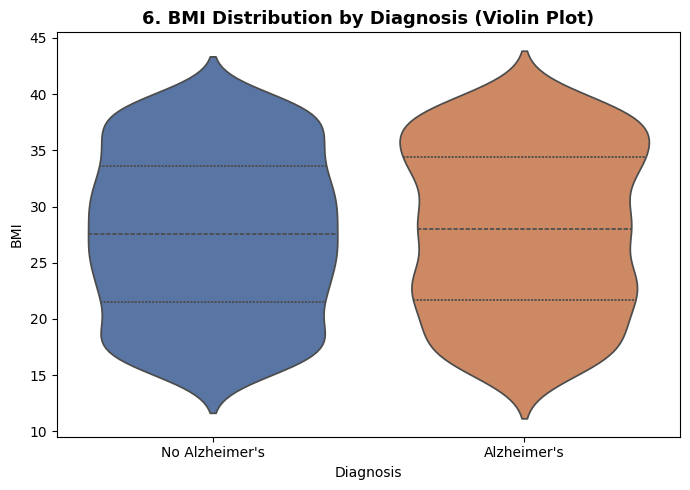

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.violinplot(data=df, x='Diagnosis_Label', y='BMI', hue='Diagnosis_Label',
               palette=colors, ax=ax, order=["No Alzheimer's", "Alzheimer's"],
               inner='quartile', legend=False)
ax.set_title("6. BMI Distribution by Diagnosis (Violin Plot)", fontsize=13, fontweight='bold')
ax.set_xlabel("Diagnosis")
ax.set_ylabel("BMI")
plt.tight_layout()
plt.show()

# 6. Summary Statistics per Classs -------------

In [12]:
print("=== Mean Values by Diagnosis Class ===\n")
summary = df.groupby('Diagnosis_Label')[['Age', 'BMI', 'MMSE',
                                          'FunctionalAssessment',
                                          'PhysicalActivity']].mean().round(2)
print(summary)

=== Mean Values by Diagnosis Class ===

                   Age    BMI   MMSE  FunctionalAssessment  PhysicalActivity
Diagnosis_Label                                                             
Alzheimer's      74.84  27.91  11.99                  3.65              4.94
No Alzheimer's   74.95  27.52  16.27                  5.86              4.91


# 7. Observations based on the analysis -------------

1. **Moderate Class Imbalance.** The dataset consists of 1,389 patients without Alzheimer's (64.6%) and 760 diagnosed with Alzheimer's (35.4%), as shown in the pie chart. This moderate imbalance suggests that model training may require resampling techniques or class weighting to avoid biased predictions toward the majority class.

2. **MMSE Score is a Strong Diagnostic Indicator.** The box plot reveals a clear and notable difference in MMSE (Mini-Mental State Examination) scores between the two groups — patients diagnosed with Alzheimer's consistently score lower than those without. This indicates that cognitive assessment score is likely one of the most discriminating features for classification.

3. **Age Distributions Overlap Significantly.** The histogram shows that both diagnostic groups are distributed across a similar age range of approximately 60 to 90 years, with no clear age threshold separating the two classes. This suggests that age alone is insufficient as a predictor, but may still serve as a contributing feature in a multi-variable model.

4. **Depression and Family History Show Higher Prevalence Among Diagnosed Patients.** The grouped bar chart reveals that patients with Alzheimer's tend to have higher rates of Depression and Family History of Alzheimer's compared to those without the condition, which aligns with established clinical risk factors for the disease.

5. **BMI Does Not Differ Significantly Between Classes.** The violin plot shows largely overlapping BMI distributions for both diagnostic groups, and the correlation heatmap confirms a near-zero correlation between BMI and Diagnosis. This suggests that BMI may contribute minimally to predictive modeling and could potentially be deprioritized during feature selection.

---
# Lab Activity 3 - Training and Comparing Five Models
# IT325 Machine Learning | Alzheimer's Disease Dataset

## Section 1 — Loading the Dataset

In [13]:
import pandas as pd

df = pd.read_csv('Gonzales_AlzheimersDisease.csv')

## Section 2 — Preprocessing and Train/Test Split

In [14]:
X = df.drop(columns=["PatientID", "Diagnosis"])
y = df["Diagnosis"]

print("Features shape:", X.shape)
print("Target shape:  ", y.shape)

Features shape: (2149, 19)
Target shape:   (2149,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set: ", X_train.shape)
print("Testing set:  ", X_test.shape)

Training set:  (1719, 19)
Testing set:   (430, 19)


In [16]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer

num_cols = X.columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), num_cols)
    ]
)

print("Preprocessing pipeline ready.")
print(f"Features to scale: {len(num_cols)}")

Preprocessing pipeline ready.
Features to scale: 19


## Section 3 — Training Five Classifiers

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

lr = Pipeline(steps=[
    ("prep",  preprocess),
    ("model", LogisticRegression(random_state=42, max_iter=1000))
])

knn = Pipeline(steps=[
    ("prep",  preprocess),
    ("model", KNeighborsClassifier())
])

dt = Pipeline(steps=[
    ("prep",  preprocess),
    ("model", DecisionTreeClassifier(random_state=42))
])

rf = Pipeline(steps=[
    ("prep",  preprocess),
    ("model", RandomForestClassifier(random_state=42, n_estimators=200))
])

nb = Pipeline(steps=[
    ("prep",  preprocess),
    ("model", GaussianNB())
])

lr.fit(X_train, y_train)
knn.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
nb.fit(X_train, y_train)

print("All five classifiers are now successfully trained!")

All five classifiers are now successfully trained!


## Section 4 — Evaluation

In [18]:
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix
)

p_lr  = lr.predict(X_test)
p_knn = knn.predict(X_test)
p_dt  = dt.predict(X_test)
p_rf  = rf.predict(X_test)
p_nb  = nb.predict(X_test)

model_preds = {
    "Logistic Regression": p_lr,
    "K-Nearest Neighbors": p_knn,
    "Decision Tree":       p_dt,
    "Random Forest":       p_rf,
    "Naive Bayes":         p_nb,
}

print("Predictions generated for all five models.")

Predictions generated for all five models.


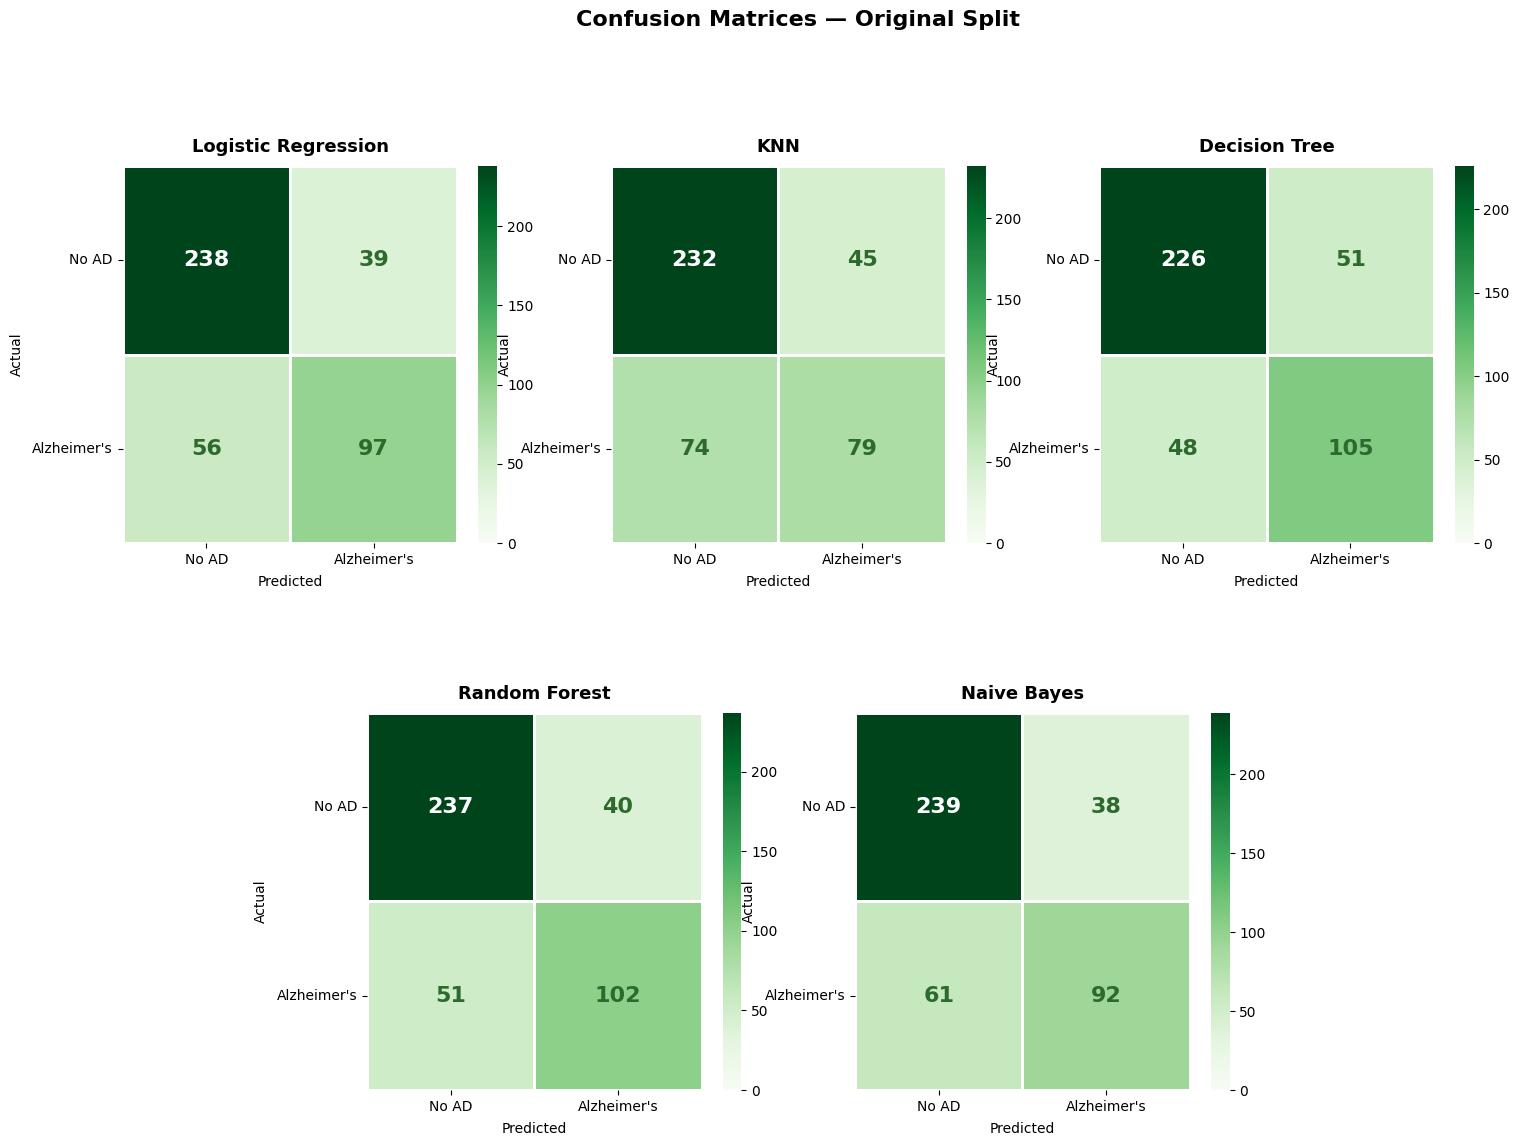

In [19]:
# Confusion Matrices — Heatmap Visual
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from sklearn.metrics import confusion_matrix

labels = ["No AD", "Alzheimer's"]

orig_pipelines = [
    ("Logistic Regression", lr),
    ("KNN",                 knn),
    ("Decision Tree",       dt),
    ("Random Forest",       rf),
    ("Naive Bayes",         nb),
]

fig = plt.figure(figsize=(18, 12))
fig.suptitle("Confusion Matrices — Original Split", fontsize=16, fontweight="bold", y=1.01)

gs = GridSpec(2, 6, figure=fig, hspace=0.45, wspace=0.4)
axes_pos = [
    gs[0, 0:2], gs[0, 2:4], gs[0, 4:6],
    gs[1, 1:3], gs[1, 3:5],
]

for ax_pos, (name, pipe) in zip(axes_pos, orig_pipelines):
    ax = fig.add_subplot(ax_pos)
    cm = confusion_matrix(y_test, pipe.predict(X_test))

    sns.heatmap(
        cm, annot=True, fmt="d", ax=ax,
        cmap="Greens", cbar=True,
        xticklabels=labels, yticklabels=labels,
        annot_kws={"size": 16, "weight": "bold"},
        linewidths=2, linecolor="white",
        vmin=0, vmax=cm.max()
    )
    for text, val in zip(ax.texts, cm.flatten()):
        text.set_color("white" if val > cm.max() * 0.5 else "#2d6a2d")

    ax.set_title(name, fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel("Predicted", fontsize=10, labelpad=6)
    ax.set_ylabel("Actual", fontsize=10, labelpad=6)
    ax.tick_params(labelsize=10)
    ax.yaxis.set_tick_params(rotation=0)

plt.show()

In [20]:
# Classification Reports
# imbalanced dataset: "NO SMOTE" (64.6% No AD vs 35.4% AD).

from sklearn.metrics import classification_report

labels = ["No Alzheimer's", "Alzheimer's"]

for name, pred in model_preds.items():
    print(f"\n{'─'*45}")
    print(f" {name}")
    print(f"{'─'*45}")
    print(classification_report(y_test, pred, target_names=labels))


─────────────────────────────────────────────
 Logistic Regression
─────────────────────────────────────────────
                precision    recall  f1-score   support

No Alzheimer's       0.81      0.86      0.83       277
   Alzheimer's       0.71      0.63      0.67       153

      accuracy                           0.78       430
     macro avg       0.76      0.75      0.75       430
  weighted avg       0.78      0.78      0.78       430


─────────────────────────────────────────────
 K-Nearest Neighbors
─────────────────────────────────────────────
                precision    recall  f1-score   support

No Alzheimer's       0.76      0.84      0.80       277
   Alzheimer's       0.64      0.52      0.57       153

      accuracy                           0.72       430
     macro avg       0.70      0.68      0.68       430
  weighted avg       0.72      0.72      0.72       430


─────────────────────────────────────────────
 Decision Tree
────────────────────────────────

In [21]:
#Comparison Table 

results = {
    "Model": [
        "Logistic Regression",
        "K-Nearest Neighbors",
        "Decision Tree",
        "Random Forest",
        "Naive Bayes"
    ],
    "Accuracy": [
        accuracy_score(y_test, p_lr),
        accuracy_score(y_test, p_knn),
        accuracy_score(y_test, p_dt),
        accuracy_score(y_test, p_rf),
        accuracy_score(y_test, p_nb)
    ],
    "Precision": [
        precision_score(y_test, p_lr),
        precision_score(y_test, p_knn),
        precision_score(y_test, p_dt),
        precision_score(y_test, p_rf),
        precision_score(y_test, p_nb)
    ],
    "Recall": [
        recall_score(y_test, p_lr),
        recall_score(y_test, p_knn),
        recall_score(y_test, p_dt),
        recall_score(y_test, p_rf),
        recall_score(y_test, p_nb)
    ],
    "F1 Score": [
        f1_score(y_test, p_lr),
        f1_score(y_test, p_knn),
        f1_score(y_test, p_dt),
        f1_score(y_test, p_rf),
        f1_score(y_test, p_nb)
    ]
}

summary = pd.DataFrame(results)
summary[["Accuracy", "Precision", "Recall", "F1 Score"]] = (
    summary[["Accuracy", "Precision", "Recall", "F1 Score"]].round(4)
)

# Highlight best value per column
print("\n=== MODEL COMPARISON TABLE ===")
display(
    summary.style
    .highlight_max(subset=["Accuracy", "Precision", "Recall", "F1 Score"],
                   color="#d4f1c4")
)


=== MODEL COMPARISON TABLE ===


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.779100,0.713200,0.634000,0.671300
1,K-Nearest Neighbors,0.723300,0.637100,0.516300,0.570400
2,Decision Tree,0.769800,0.673100,0.686300,0.679600
3,Random Forest,0.788400,0.718300,0.666700,0.691500
4,Naive Bayes,0.769800,0.707700,0.601300,0.650200


## Section 5 — Handling Class Imbalance with SMOTE

> **Why SMOTE?** The dataset has an imbalanced class distribution: ~64.6% No Alzheimer's (0) vs ~35.4% Alzheimer's (1). Training on imbalanced data causes models to be biased toward the majority class. 

In [22]:
# Check original class distribution before SMOTE
print("Original class distribution:")
print(y.value_counts())
print(f"\nRatio — No Alzheimer's : Alzheimer's = "
      f"{y.value_counts()[0]} : {y.value_counts()[1]}")

Original class distribution:
Diagnosis
0    1389
1     760
Name: count, dtype: int64

Ratio — No Alzheimer's : Alzheimer's = 1389 : 760


In [23]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

lr_s = ImbPipeline(steps=[
    ("scaler", MinMaxScaler()),
    ("smote",  SMOTE(random_state=42)),
    ("model",  LogisticRegression(random_state=42, max_iter=1000))
])

knn_s = ImbPipeline(steps=[
    ("scaler", MinMaxScaler()),
    ("smote",  SMOTE(random_state=42)),
    ("model",  KNeighborsClassifier())
])

dt_s = ImbPipeline(steps=[
    ("scaler", MinMaxScaler()),
    ("smote",  SMOTE(random_state=42)),
    ("model",  DecisionTreeClassifier(random_state=42))
])

rf_s = ImbPipeline(steps=[
    ("scaler", MinMaxScaler()),
    ("smote",  SMOTE(random_state=42)),
    ("model",  RandomForestClassifier(random_state=42, n_estimators=200))
])

nb_s = ImbPipeline(steps=[
    ("scaler", MinMaxScaler()),
    ("smote",  SMOTE(random_state=42)),
    ("model",  GaussianNB())
])

print("SMOTE pipelines ready.")

SMOTE pipelines ready.


## Section 6 — 5-Fold Stratified Cross-Validation

In [24]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy":  make_scorer(accuracy_score),
    "precision": make_scorer(precision_score),
    "recall":    make_scorer(recall_score),
    "f1":        make_scorer(f1_score),
}

smote_models = {
    "Logistic Regression": lr_s,
    "K-Nearest Neighbors": knn_s,
    "Decision Tree":       dt_s,
    "Random Forest":       rf_s,
    "Naive Bayes":         nb_s,
}

cv_results = {}
for name, pipe in smote_models.items():
    cv = cross_validate(
        pipe, X_train, y_train,
        cv=skf, scoring=scoring,
        return_train_score=False
    )
    cv_results[name] = {
        "Accuracy":   cv["test_accuracy"].mean(),
        "Precision":  cv["test_precision"].mean(),
        "Recall":     cv["test_recall"].mean(),
        "F1 Score":   cv["test_f1"].mean(),
        "Acc ± Std":  cv["test_accuracy"].std(),
        "F1 ± Std":   cv["test_f1"].std(),
    }
    print(f"{name}:")
    print(f"  Accuracy  = {cv_results[name]['Accuracy']:.4f} ")
    print(f"  Precision = {cv_results[name]['Precision']:.4f}")
    print(f"  Recall    = {cv_results[name]['Recall']:.4f}")
    print(f"  F1 Score  = {cv_results[name]['F1 Score']:.4f} ")
    print()

print("5-fold cross-validation complete.")

Logistic Regression:
  Accuracy  = 0.7574 
  Precision = 0.6316
  Recall    = 0.7546
  F1 Score  = 0.6872 

K-Nearest Neighbors:
  Accuracy  = 0.6707 
  Precision = 0.5274
  Recall    = 0.6540
  F1 Score  = 0.5839 

Decision Tree:
  Accuracy  = 0.7504 
  Precision = 0.6377
  Recall    = 0.6822
  F1 Score  = 0.6588 

Random Forest:
  Accuracy  = 0.7906 
  Precision = 0.6920
  Recall    = 0.7365
  F1 Score  = 0.7130 

Naive Bayes:
  Accuracy  = 0.7283 
  Precision = 0.6009
  Recall    = 0.6887
  F1 Score  = 0.6416 

5-fold cross-validation complete.


In [25]:
# Cross-Validation Comparison Table with Std
cv_df = pd.DataFrame([
    {"Model": name,
     "CV Accuracy":  round(v["Accuracy"],  4),
     "CV Precision": round(v["Precision"], 4),
     "CV Recall":    round(v["Recall"],    4),
     "CV F1 Score":  round(v["F1 Score"],  4),
    }
    for name, v in cv_results.items()
])

print("=== 5-Fold Cross-Validation Results (with SMOTE) ===")
display(
    cv_df.style
    .highlight_max(subset=["CV Accuracy","CV Precision","CV Recall","CV F1 Score"],
                   color="#d4f1c4")
    .set_caption("Green = best CV score per metric | SMOTE applied on training folds only")
)

=== 5-Fold Cross-Validation Results (with SMOTE) ===


,Model,CV Accuracy,CV Precision,CV Recall,CV F1 Score
0,Logistic Regression,0.757400,0.631600,0.754600,0.687200
1,K-Nearest Neighbors,0.670700,0.527400,0.654000,0.583900
2,Decision Tree,0.750400,0.637700,0.682200,0.658800
3,Random Forest,0.790600,0.692000,0.736500,0.713000
4,Naive Bayes,0.728300,0.600900,0.688700,0.641600


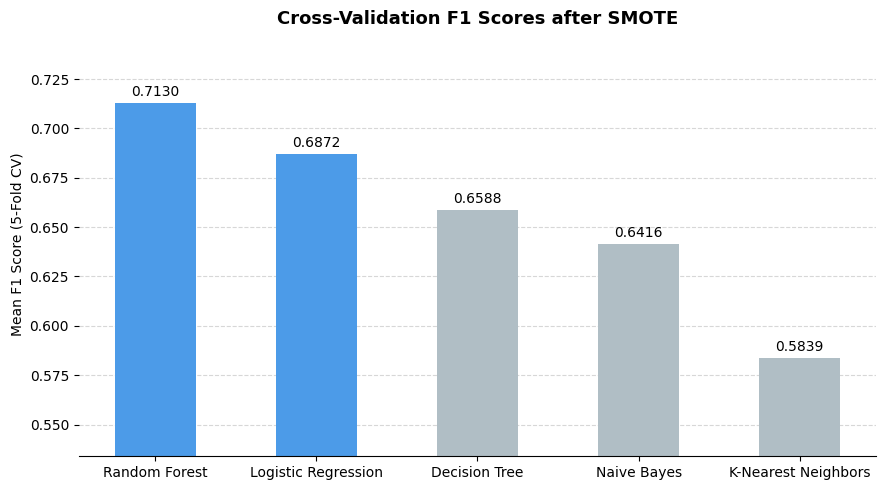

In [26]:
# Cross-Validation F1 Scores after SMOTE — Bar Chart
import matplotlib.pyplot as plt
import numpy as np

model_order = sorted(cv_results.keys(), key=lambda k: cv_results[k]["F1 Score"].mean(), reverse=True)
f1_means    = [cv_results[k]["F1 Score"].mean() for k in model_order]
bar_colors  = ["#4C9BE8" if i < 2 else "#B0BEC5" for i in range(len(model_order))]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(model_order, f1_means, color=bar_colors, edgecolor="none", width=0.5)

for bar, val in zip(bars, f1_means):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f"{val:.4f}",
            ha="center", va="bottom", fontsize=10)

ax.set_title("Cross-Validation F1 Scores after SMOTE", fontsize=13, fontweight="bold")
ax.set_ylabel("Mean F1 Score (5-Fold CV)", fontsize=10)
ax.set_ylim(bottom=min(f1_means) - 0.05)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

---
# === Final Model: Training, Evaluation & Export ===

       HYPERPARAMETER TUNING STAGE

 Tuning Logistic Regression...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

 Best LR Parameters : {'model__C': 0.1, 'model__l1_ratio': 1.0, 'model__solver': 'saga'}

 Tuning Random Forest...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

 Best RF Parameters : {'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_split': 2, 'model__n_estimators': 200}

            BEFORE vs AFTER TUNING
Model                                      Accuracy  Precision     Recall         F1
----------------------------------------------------------------------
Logistic Regression (Before)                0.7605    0.6330    0.7778    0.6979
Random Forest (Before)                      0.7977    0.6988    0.7582    0.7273
Logistic Regression (After)                 0.7628    0.6335    0.7908    0.7035
Random Forest (After)                       0.7930    0.6778    0.7974    0.7327


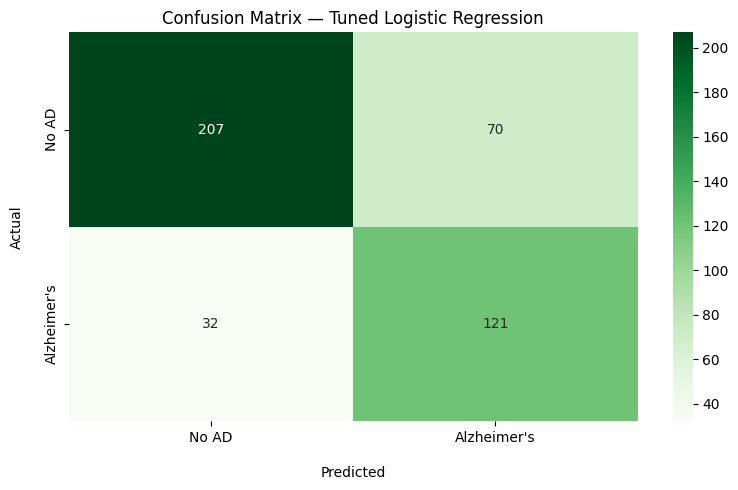


--- Tuned Logistic Regression ---
True Negatives  (Correctly No AD)      : 207
False Positives (Wrongly flagged AD)   : 70
False Negatives (Missed AD cases)      : 32
True Positives  (Correctly caught AD)  : 121


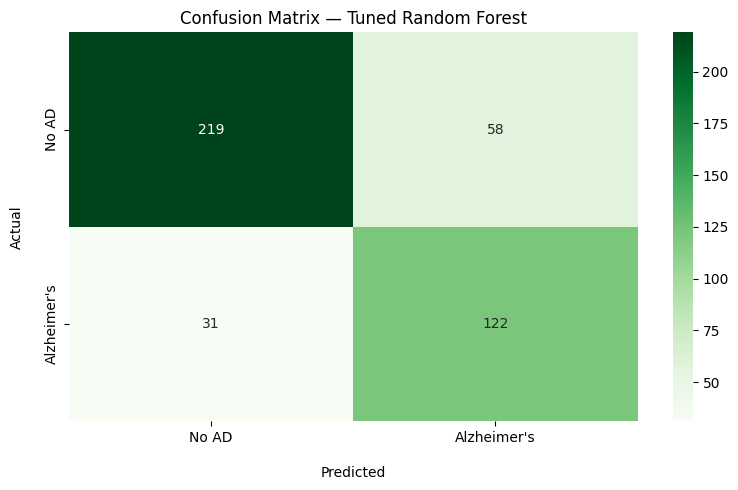


--- Tuned Random Forest ---
True Negatives  (Correctly No AD)      : 219
False Positives (Wrongly flagged AD)   : 58
False Negatives (Missed AD cases)      : 31
True Positives  (Correctly caught AD)  : 122

 WINNER MODEL FOR DEPLOYMENT
Tuned Logistic Regression F1 : 0.7035
Tuned Random Forest F1       : 0.7327

 WINNER: Tuned Random Forest!

 PKL file saved!
Final model type : RandomForestClassifier
Final parameters : {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [30]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib, os

print("=" * 60)
print("       HYPERPARAMETER TUNING STAGE")
print("=" * 60)

# ─────────────────────────────────────────────────────────────
# 1. TUNE LOGISTIC REGRESSION
# ─────────────────────────────────────────────────────────────
print("\n Tuning Logistic Regression...")

lr_tune_pipe = ImbPipeline([
    ("scaler", MinMaxScaler()),
    ("smote",  SMOTE(random_state=42)),
    ("model",  LogisticRegression(random_state=42, max_iter=1000)),
])

lr_param_grid = {
    "model__C":        [0.01, 0.1, 1, 10, 100],
    "model__l1_ratio": [0.0, 1.0],
    "model__solver":   ["saga"],
}

lr_grid = GridSearchCV(
    lr_tune_pipe,
    lr_param_grid, cv=5, scoring="f1",
    n_jobs=-1, verbose=1
)
lr_grid.fit(X_train, y_train)

best_lr_model  = lr_grid.best_estimator_
lr_predictions = best_lr_model.predict(X_test)

print(f"\n Best LR Parameters : {lr_grid.best_params_}")

# ─────────────────────────────────────────────────────────────
# 2. TUNE RANDOM FOREST
# ─────────────────────────────────────────────────────────────
print("\n Tuning Random Forest...")

rf_tune_pipe = ImbPipeline([
    ("scaler", MinMaxScaler()),
    ("smote",  SMOTE(random_state=42)),
    ("model",  RandomForestClassifier(random_state=42)),
])

rf_param_grid = {
    "model__n_estimators":      [100, 200, 300],
    "model__max_depth":         [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__max_features":      ["sqrt", "log2"],
}

rf_grid = GridSearchCV(
    rf_tune_pipe,
    rf_param_grid, cv=5, scoring="f1",
    n_jobs=-1, verbose=1
)
rf_grid.fit(X_train, y_train)

best_rf_model  = rf_grid.best_estimator_
rf_predictions = best_rf_model.predict(X_test)

print(f"\n Best RF Parameters : {rf_grid.best_params_}")

# ─────────────────────────────────────────────────────────────
# 3. BEFORE vs AFTER COMPARISON TABLE
# ─────────────────────────────────────────────────────────────
# Fit the baseline models first (CV does not permanently fit them)
lr_s.fit(X_train, y_train)
rf_s.fit(X_train, y_train)

print("\n" + "=" * 70)
print("            BEFORE vs AFTER TUNING")
print("=" * 70)
print(f"{'Model':<40} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 70)

comparisons = [
    ("Logistic Regression (Before)", lr_s.predict(X_test)),
    ("Random Forest (Before)",       rf_s.predict(X_test)),
    ("Logistic Regression (After)",  lr_predictions),
    ("Random Forest (After)",        rf_predictions),
]

for name, preds in comparisons:
    print(f"{name:<40}"
          f"{accuracy_score(y_test, preds):>10.4f}"
          f"{precision_score(y_test, preds, zero_division=0):>10.4f}"
          f"{recall_score(y_test, preds, zero_division=0):>10.4f}"
          f"{f1_score(y_test, preds, zero_division=0):>10.4f}")

# ─────────────────────────────────────────────────────────────
# 4. CONFUSION MATRICES FOR TUNED MODELS
# ─────────────────────────────────────────────────────────────
for name, preds in [("Tuned Logistic Regression", lr_predictions),
                     ("Tuned Random Forest",        rf_predictions)]:
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(8, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
                xticklabels=["No AD", "Alzheimer's"],
                yticklabels=["No AD", "Alzheimer's"])
    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted", labelpad=15)
    plt.ylabel("Actual",    labelpad=15)
    plt.tight_layout()
    plt.show()

    tn, fp, fn, tp = cm.ravel()
    print(f"\n--- {name} ---")
    print(f"True Negatives  (Correctly No AD)      : {tn}")
    print(f"False Positives (Wrongly flagged AD)   : {fp}")
    print(f"False Negatives (Missed AD cases)      : {fn}")
    print(f"True Positives  (Correctly caught AD)  : {tp}")

# ─────────────────────────────────────────────────────────────
# 5. WINNER SELECTION USING F1
# ─────────────────────────────────────────────────────────────
lr_f1 = f1_score(y_test, lr_predictions)
rf_f1 = f1_score(y_test, rf_predictions)

print("\n" + "=" * 60)
print(" WINNER MODEL FOR DEPLOYMENT")
print("=" * 60)
print(f"Tuned Logistic Regression F1 : {lr_f1:.4f}")
print(f"Tuned Random Forest F1       : {rf_f1:.4f}")

if rf_f1 >= lr_f1:
    print(f"\n WINNER: Tuned Random Forest!")
    final_model = best_rf_model
else:
    print(f"\n WINNER: Tuned Logistic Regression!")
    final_model = best_lr_model

# ─────────────────────────────────────────────────────────────
# 6. SAVE PKL FILE
# ─────────────────────────────────────────────────────────────
os.makedirs("models", exist_ok=True)
joblib.dump(final_model, "models/rf_model.pkl")

print("\n PKL file saved!")
print(f"Final model type : {type(final_model.named_steps['model']).__name__}")
print(f"Final parameters : {final_model.named_steps['model'].get_params()}")